In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
# load data
df = pd.read_csv("inventory.csv")
print(f"Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

# filter for North region
df = df[df['Regional'] == 'North'].copy()
print(f"North region: {df.shape[0]:,} rows")

# convert date and add time features
df['Date'] = pd.to_datetime(df['Date'], format="%d/%m/%Y")
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['Week_of_Year'] = df['Date'].dt.isocalendar().week

# drop unnecessary columns
df = df.drop(columns=['ProductID', 'Seasonality', 'Regional'])

print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")
df.head()

Data loaded: 73,100 rows × 15 columns
North region: 18,228 rows
Date range: 2022-01-01 00:00:00 to 2024-01-01 00:00:00


,Date,Store,InventoryQuant,Sold,units_ordered,Demand Forecast,Price,Discount,Weather,Promotion,Competitor Pricing,product_category,Month,Quarter,Week_of_Year
0,2022-01-01,S001,231,127,55,135.47,33.50,20,Rainy,0,29.69,Groceries,1,1,52
3,2022-01-01,S001,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Toys,1,1,52
7,2022-01-01,S001,380,312,54,329.73,97.99,5,Cloudy,0,100.09,Clothing,1,1,52
14,2022-01-01,S001,379,369,154,363.46,92.99,15,Snowy,0,95.80,Clothing,1,1,52
15,2022-01-01,S001,363,255,69,255.74,21.90,5,Cloudy,1,20.27,Electronics,1,1,52


In [ ]:
df_weekly = (
    df
    .groupby([pd.Grouper(key='Date', freq='W'), 'Store', 'product_category'])
    .agg({
        'units_ordered': 'sum', # target
        'Sold': 'sum',
        'InventoryQuant': 'mean',
        'Demand Forecast': 'sum',
        'Price': 'mean',
        'Discount': 'mean',
        'Promotion': 'sum',
        'Competitor Pricing': 'mean',
        'Weather': 'first',
        'Month': 'first',
        'Quarter': 'first',
        'Week_of_Year': 'first'
    })
    .reset_index()
    .sort_values(['Store', 'product_category', 'Date'])
    .reset_index(drop=True)
)

print(f"Total samples: {df_weekly.shape[0]:,}")
print(f"Weeks: {df_weekly['Date'].nunique()}")
print(f"Stores: {df_weekly['Store'].nunique()}")
print(f"Categories: {df_weekly['product_category'].nunique()}")

df_weekly.head()

Total samples: 2,634
Weeks: 106
Stores: 5
Categories: 5


,Date,Store,product_category,units_ordered,Sold,InventoryQuant,Demand Forecast,Price,Discount,Promotion,Competitor Pricing,Weather,Month,Quarter,Week_of_Year
0,2022-01-02,S001,Clothing,371,720,310.0,740.99,67.473333,8.333333,0,69.533333,Cloudy,1,1,52
1,2022-01-09,S001,Clothing,745,1237,297.0,1297.09,71.728750,8.125000,4,70.292500,Sunny,1,1,1
2,2022-01-16,S001,Clothing,1106,1296,246.0,1375.66,45.655556,11.666667,6,45.351111,Cloudy,1,1,2
3,2022-01-23,S001,Clothing,407,340,214.5,348.15,75.825000,8.750000,2,76.262500,Sunny,1,1,3
4,2022-01-30,S001,Clothing,617,946,281.0,990.55,65.448333,7.500000,4,65.320000,Cloudy,1,1,4


In [ ]:
df_features = df_weekly.copy()

# lagged sales
for lag in [1, 2, 4]:
    df_features[f'Lagged_Sold_{lag}w'] = (
        df_features.groupby(['Store', 'product_category'])['Sold']
        .shift(lag).fillna(0)
    )

# rolling stats
df_features['Rolling_Sold_4w'] = (
    df_features.groupby(['Store', 'product_category'])['Sold']
    .transform(lambda x: x.rolling(window=4, min_periods=1).mean().shift(1))
    .fillna(0)
)

df_features['Rolling_Sold_std_4w'] = (
    df_features.groupby(['Store', 'product_category'])['Sold']
    .transform(lambda x: x.rolling(window=4, min_periods=1).std().shift(1))
    .fillna(0)
)

# inventory coverage
df_features['Stock_Coverage_Weeks'] = (
    df_features['InventoryQuant'] / df_features['Lagged_Sold_1w'].replace(0, 1)
).clip(0, 10)

# demand velocity
df_features['Sales_Velocity'] = (
    (df_features['Lagged_Sold_1w'] - df_features['Lagged_Sold_2w']) /
    df_features['Lagged_Sold_2w'].replace(0, 1)
).clip(-2, 2)

# forecast reliability
df_features['Forecast_vs_Actual'] = (
    df_features['Demand Forecast'] / df_features['Lagged_Sold_1w'].replace(0, 1)
).clip(0, 5)

# pricing effects
df_features['Price_vs_Competitor'] = df_features['Price'] - df_features['Competitor Pricing']
df_features['Price_Promo_Interaction'] = df_features['Price'] * df_features['Promotion']
df_features['Discount_Promo_Interaction'] = df_features['Discount'] * df_features['Promotion']

# time features
df_features['Month_Sin'] = np.sin(2 * np.pi * df_features['Month'] / 12)
df_features['Month_Cos'] = np.cos(2 * np.pi * df_features['Month'] / 12)
df_features['Week_Sin'] = np.sin(2 * np.pi * df_features['Week_of_Year'] / 52)
df_features['Week_Cos'] = np.cos(2 * np.pi * df_features['Week_of_Year'] / 52)

# delivery cycle
delivery_cycle = {
    'Groceries': 1,
    'Toys': 3,
    'Clothing': 3,
    'Furniture': 7,
    'Electronics': 7
}
df_features['Delivery_Cycle'] = df_features['product_category'].map(delivery_cycle)

# drop current week's sales
df_features = df_features.drop(columns=['Sold'])

# handle empty values
num_cols = df_features.select_dtypes(include=[float, int]).columns
df_features[num_cols] = df_features[num_cols].fillna(df_features[num_cols].median())

In [ ]:
# one-hot encoding
df_model = df_features.copy()
df_model = pd.get_dummies(
    df_model,
    columns=['product_category', 'Store', 'Weather'],
    drop_first=False,
    dtype='uint8'
)

# separate targets and features
y = df_model['units_ordered'].copy()
X = df_model.drop(columns=['units_ordered', 'Date'])

# time-based split (80 and 20)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y.iloc[:split_idx].copy(), y.iloc[split_idx:].copy()

# scale numeric features
scaler = StandardScaler()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print(f"Features: {X.shape[1]}")
print(f"Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test samples: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Target mean: {y_train.mean():.2f} units")
print(f"Target std: {y_train.std():.2f} units")

Features: 39
Training samples: 2,107 (80.0%)
Test samples: 527 (20.0%)
Target mean: 759.99 units
Target std: 320.53 units


In [ ]:
print("MODEL 1: BASELINE CATBOOST")

baseline_model = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=9,
    subsample=0.8,
    random_state=42,
    verbose=0
)

baseline_model.fit(X_train, y_train)

# predictions
y_pred_train_baseline = baseline_model.predict(X_train)
y_pred_test_baseline = baseline_model.predict(X_test)

# metrics
train_r2_baseline = r2_score(y_train, y_pred_train_baseline)
test_r2_baseline = r2_score(y_test, y_pred_test_baseline)
train_mae_baseline = mean_absolute_error(y_train, y_pred_train_baseline)
test_mae_baseline = mean_absolute_error(y_test, y_pred_test_baseline)
train_rmse_baseline = np.sqrt(mean_squared_error(y_train, y_pred_train_baseline))
test_rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_test_baseline))
gap_baseline = train_r2_baseline - test_r2_baseline

print(f"\nBASELINE PERFORMANCE:")
print(f"Train R²:        {train_r2_baseline:.4f}")
print(f"Test R²:         {test_r2_baseline:.4f}")
print(f"Train MAE:       {train_mae_baseline:.2f} units")
print(f"Test MAE:        {test_mae_baseline:.2f} units")
print(f"Train RMSE:      {train_rmse_baseline:.2f} units")
print(f"Test RMSE:       {test_rmse_baseline:.2f} units")
print(f"Overfitting Gap: {gap_baseline:.4f}")

MODEL 1: BASELINE CATBOOST

BASELINE PERFORMANCE:
Train R²:        0.8285
Test R²:         0.6345
Train MAE:       104.82 units
Test MAE:        144.70 units
Train RMSE:      132.70 units
Test RMSE:       191.93 units
Overfitting Gap: 0.1941


In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': baseline_model.feature_importances_
}).sort_values('Importance', ascending=False)

# select top 20 features
top_features = feature_importance.head(20)['Feature'].tolist()
X_train_selected = X_train[top_features].copy()
X_test_selected = X_test[top_features].copy()

print(f"\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))


Top 20 Most Important Features:
                   Feature  Importance
           Demand Forecast   32.015780
            InventoryQuant    9.008310
                 Promotion    9.000546
   Price_Promo_Interaction    6.073134
Discount_Promo_Interaction    4.708196
                  Discount    3.941988
       Rolling_Sold_std_4w    3.155904
        Forecast_vs_Actual    2.741552
       Price_vs_Competitor    2.678371
                     Price    2.647485
           Rolling_Sold_4w    2.638659
            Lagged_Sold_4w    2.367596
            Sales_Velocity    2.234558
            Lagged_Sold_2w    1.845719
      Stock_Coverage_Weeks    1.781098
        Competitor Pricing    1.599934
            Lagged_Sold_1w    1.562976
                  Week_Cos    1.348175
                  Week_Sin    1.228200
              Week_of_Year    0.858320


In [ ]:
print("MODEL 2: XGBOOST")


xgboost_model = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    reg_alpha=1, # L1 regularization
    reg_lambda=9, # L2 regularization
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgboost_model.fit(X_train_selected, y_train)

# predictions
y_pred_train_xgboost = xgboost_model.predict(X_train_selected)
y_pred_test_xgboost = xgboost_model.predict(X_test_selected)

# metrics
train_r2_xgboost = r2_score(y_train, y_pred_train_xgboost)
test_r2_xgboost = r2_score(y_test, y_pred_test_xgboost)
train_mae_xgboost = mean_absolute_error(y_train, y_pred_train_xgboost)
test_mae_xgboost = mean_absolute_error(y_test, y_pred_test_xgboost)
train_rmse_xgboost = np.sqrt(mean_squared_error(y_train, y_pred_train_xgboost))
test_rmse_xgboost = np.sqrt(mean_squared_error(y_test, y_pred_test_xgboost))
gap_xgboost = train_r2_xgboost - test_r2_xgboost

print(f"\nXGBOOST PERFORMANCE:")
print(f"Train R²:        {train_r2_xgboost:.4f}")
print(f"Test R²:         {test_r2_xgboost:.4f}")
print(f"Train MAE:       {train_mae_xgboost:.2f} units")
print(f"Test MAE:        {test_mae_xgboost:.2f} units")
print(f"Train RMSE:      {train_rmse_xgboost:.2f} units")
print(f"Test RMSE:       {test_rmse_xgboost:.2f} units")
print(f"Overfitting Gap: {gap_xgboost:.4f}")

MODEL 2: XGBOOST

XGBOOST PERFORMANCE:
Train R²:        0.9838
Test R²:         0.6097
Train MAE:       28.89 units
Test MAE:        150.26 units
Train RMSE:      40.80 units
Test RMSE:       198.33 units
Overfitting Gap: 0.3741


In [ ]:
print("="*70)
print("MODEL 3: OPTIMIZED CATBOOST")
print("="*70)

optimized_model = CatBoostRegressor(
    iterations=800,          # before: 500
    depth=3,                 # before: 6
    learning_rate=0.03,      # before: 0.05
    l2_leaf_reg=50,         # before: 9
    subsample=0.7,          # before: 0.8
    colsample_bylevel=0.7,  # use 70% of features per level
    random_state=42,
    verbose=0
)

optimized_model.fit(X_train_selected, y_train)

# predictions
y_pred_train_optimized = optimized_model.predict(X_train_selected)
y_pred_test_optimized = optimized_model.predict(X_test_selected)

# metrics
train_r2_optimized = r2_score(y_train, y_pred_train_optimized)
test_r2_optimized = r2_score(y_test, y_pred_test_optimized)
train_mae_optimized = mean_absolute_error(y_train, y_pred_train_optimized)
test_mae_optimized = mean_absolute_error(y_test, y_pred_test_optimized)
train_rmse_optimized = np.sqrt(mean_squared_error(y_train, y_pred_train_optimized))
test_rmse_optimized = np.sqrt(mean_squared_error(y_test, y_pred_test_optimized))
gap_optimized = train_r2_optimized - test_r2_optimized

print(f"\nOPTIMIZED CATBOOST PERFORMANCE:")
print(f"Train R²:        {train_r2_optimized:.4f}")
print(f"Test R²:         {test_r2_optimized:.4f}")
print(f"Train MAE:       {train_mae_optimized:.2f} units")
print(f"Test MAE:        {test_mae_optimized:.2f} units")
print(f"Train RMSE:      {train_rmse_optimized:.2f} units")
print(f"Test RMSE:       {test_rmse_optimized:.2f} units")
print(f"Overfitting Gap: {gap_optimized:.4f}")

MODEL 3: OPTIMIZED CATBOOST

OPTIMIZED CATBOOST PERFORMANCE:
Train R²:        0.6922
Test R²:         0.6484
Train MAE:       141.05 units
Test MAE:        142.58 units
Train RMSE:      177.78 units
Test RMSE:       188.23 units
Overfitting Gap: 0.0438


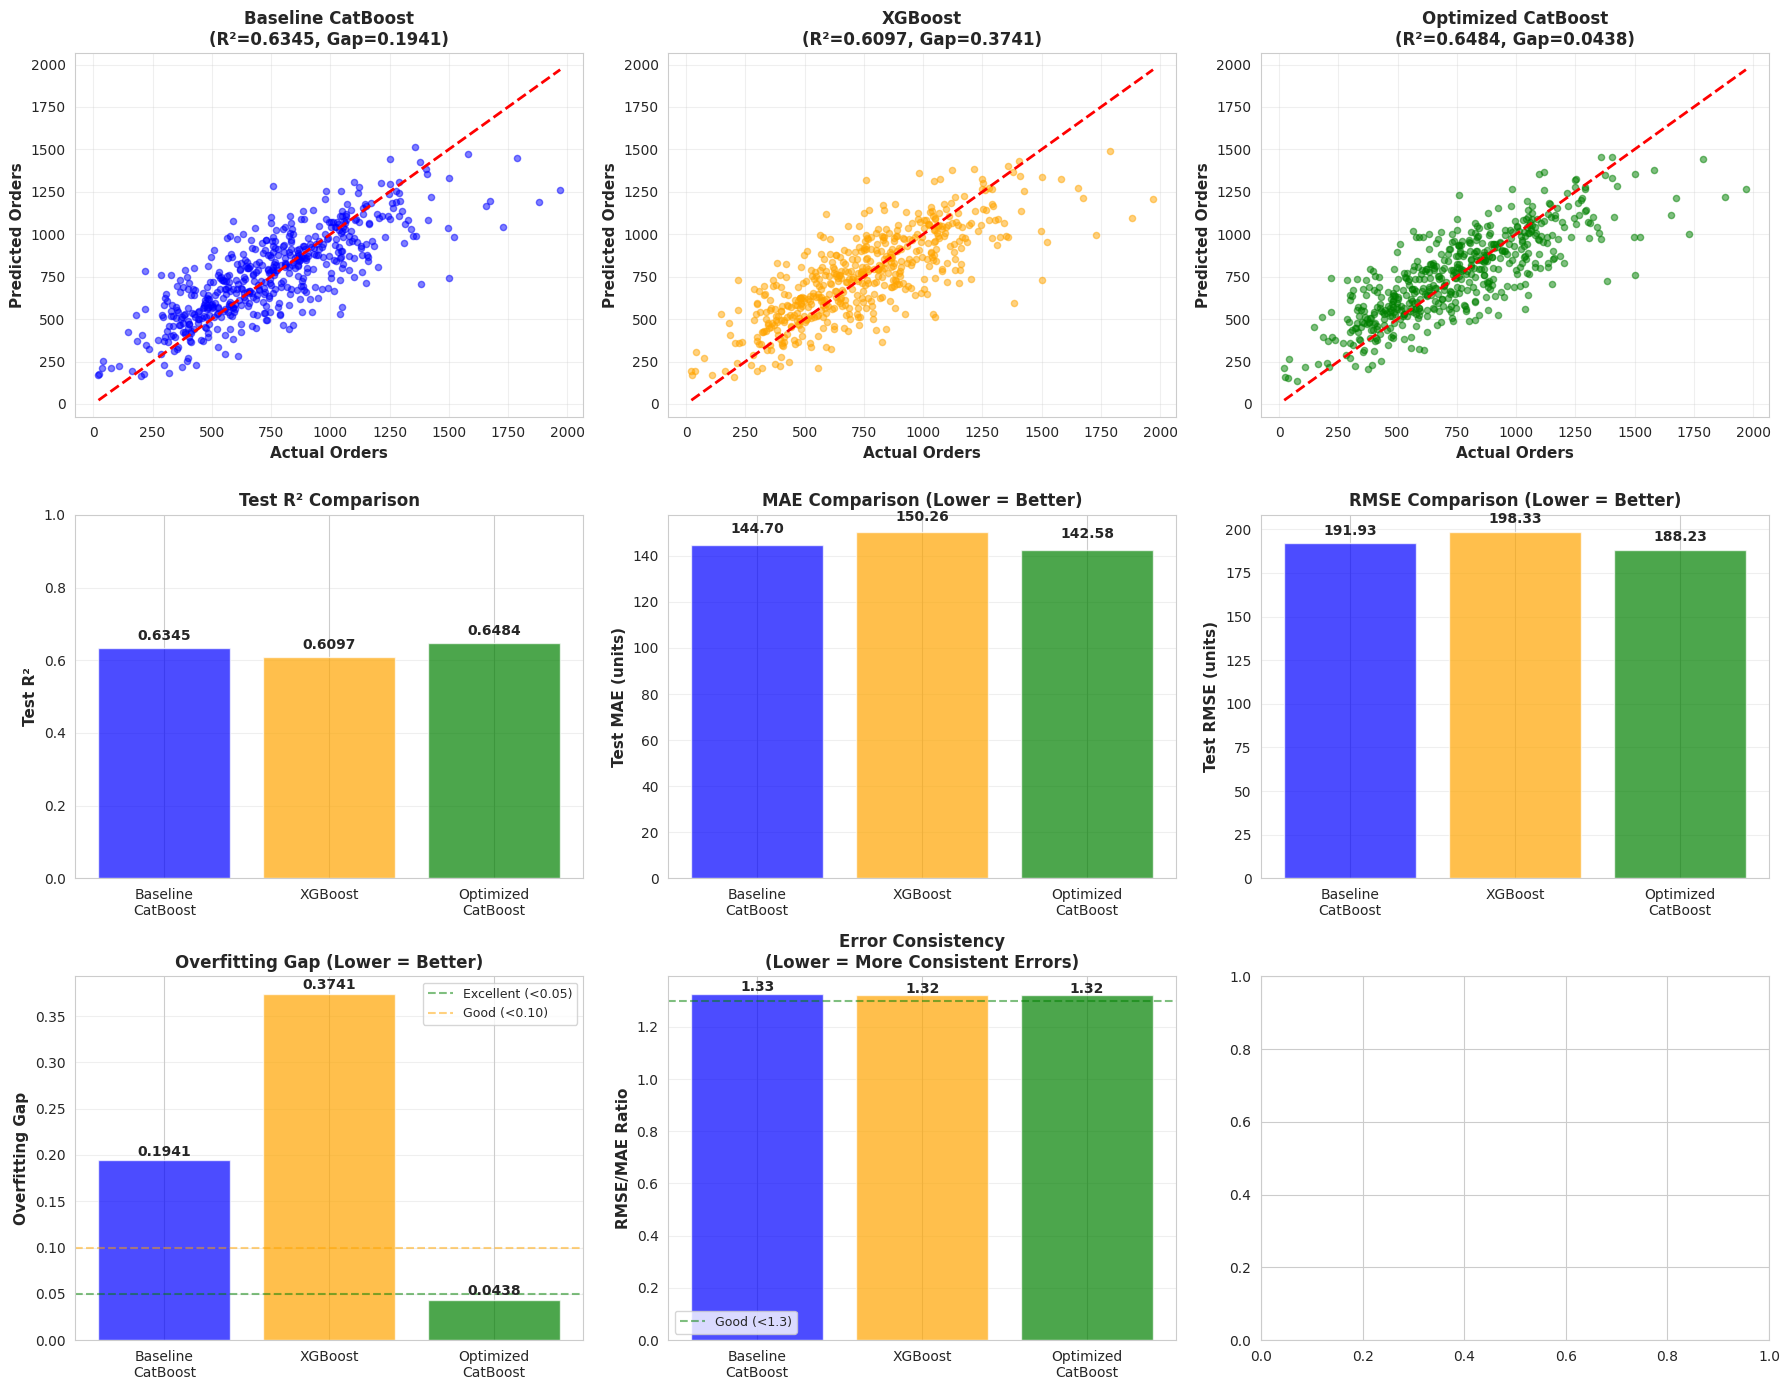

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# predicted vs actual (Baseline CatBoost)
ax = axes[0, 0]
ax.scatter(y_test, y_pred_test_baseline, alpha=0.5, s=20, color='blue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Orders', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Orders', fontsize=11, fontweight='bold')
ax.set_title(f'Baseline CatBoost\n(R²={test_r2_baseline:.4f}, Gap={gap_baseline:.4f})',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# predicted vs actual (XGBoost)
ax = axes[0, 1]
ax.scatter(y_test, y_pred_test_xgboost, alpha=0.5, s=20, color='orange')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Orders', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Orders', fontsize=11, fontweight='bold')
ax.set_title(f'XGBoost\n(R²={test_r2_xgboost:.4f}, Gap={gap_xgboost:.4f})',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# predicted vs actual (Optimised CatBoost)
ax = axes[0, 2]
ax.scatter(y_test, y_pred_test_optimized, alpha=0.5, s=20, color='green')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Orders', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted Orders', fontsize=11, fontweight='bold')
ax.set_title(f'Optimized CatBoost\n(R²={test_r2_optimized:.4f}, Gap={gap_optimized:.4f})',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# Model Comparison: R²
ax = axes[1, 0]
models_names = ['Baseline\nCatBoost', 'XGBoost', 'Optimized\nCatBoost']
test_r2_values = [test_r2_baseline, test_r2_xgboost, test_r2_optimized]
colors = ['blue', 'orange', 'green']
bars = ax.bar(models_names, test_r2_values, color=colors, alpha=0.7)
ax.set_ylabel('Test R²', fontsize=11, fontweight='bold')
ax.set_title('Test R² Comparison', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, test_r2_values)):
    ax.text(i, val + 0.02, f'{val:.4f}', ha='center', fontweight='bold')

# Model Comparison: MAE
ax = axes[1, 1]
mae_values = [test_mae_baseline, test_mae_xgboost, test_mae_optimized]
bars = ax.bar(models_names, mae_values, color=colors, alpha=0.7)
ax.set_ylabel('Test MAE (units)', fontsize=11, fontweight='bold')
ax.set_title('MAE Comparison (Lower = Better)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, mae_values)):
    ax.text(i, val + 5, f'{val:.2f}', ha='center', fontweight='bold')

# Model Comparison: RMSE
ax = axes[1, 2]
rmse_values = [test_rmse_baseline, test_rmse_xgboost, test_rmse_optimized]
bars = ax.bar(models_names, rmse_values, color=colors, alpha=0.7)
ax.set_ylabel('Test RMSE (units)', fontsize=11, fontweight='bold')
ax.set_title('RMSE Comparison (Lower = Better)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, rmse_values)):
    ax.text(i, val + 5, f'{val:.2f}', ha='center', fontweight='bold')

# Model Comparison: Overfitting Gap
ax = axes[2, 0]
gap_values = [gap_baseline, gap_xgboost, gap_optimized]
bars = ax.bar(models_names, gap_values, color=colors, alpha=0.7)
ax.set_ylabel('Overfitting Gap', fontsize=11, fontweight='bold')
ax.set_title('Overfitting Gap (Lower = Better)', fontsize=12, fontweight='bold')
ax.axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='Excellent (<0.05)')
ax.axhline(y=0.10, color='orange', linestyle='--', alpha=0.5, label='Good (<0.10)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, gap_values)):
    ax.text(i, val + 0.005, f'{val:.4f}', ha='center', fontweight='bold')

# RMSE/MAE Ratio (Error Consistency)
ax = axes[2, 1]
ratio_values = [test_rmse_baseline/test_mae_baseline, test_rmse_xgboost/test_mae_xgboost, test_rmse_optimized/test_mae_optimized]
bars = ax.bar(models_names, ratio_values, color=colors, alpha=0.7)
ax.set_ylabel('RMSE/MAE Ratio', fontsize=11, fontweight='bold')
ax.set_title('Error Consistency\n(Lower = More Consistent Errors)', fontsize=12, fontweight='bold')
ax.axhline(y=1.3, color='green', linestyle='--', alpha=0.5, label='Good (<1.3)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, ratio_values)):
    ax.text(i, val + 0.01, f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# create comparison table
comparison_data = {
    'Metric': ['Train R²', 'Test R²', 'Test MAE (units)', 'Test RMSE (units)', 'Overfitting Gap', 'RMSE/MAE Ratio'],
    'Baseline CatBoost': [
        f"{train_r2_baseline:.4f}",
        f"{test_r2_baseline:.4f}",
        f"{test_mae_baseline:.2f}",
        f"{test_rmse_baseline:.2f}",
        f"{gap_baseline:.4f}",
        f"{test_rmse_baseline/test_mae_baseline:.2f}"
    ],
    'XGBoost': [
        f"{train_r2_xgboost:.4f}",
        f"{test_r2_xgboost:.4f}",
        f"{test_mae_xgboost:.2f}",
        f"{test_rmse_xgboost:.2f}",
        f"{gap_xgboost:.4f}",
        f"{test_rmse_xgboost/test_mae_xgboost:.2f}"
    ],
    'Optimized CatBoost': [
        f"{train_r2_optimized:.4f}",
        f"{test_r2_optimized:.4f}",
        f"{test_mae_optimized:.2f}",
        f"{test_rmse_optimized:.2f}",
        f"{gap_optimized:.4f}",
        f"{test_rmse_optimized/test_mae_optimized:.2f}"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

print("="*100)
print("FINAL MODEL COMPARISON")
print("="*100)
print(df_comparison.to_string(index=False))

# determine best model
models_summary = [
    {'name': 'Baseline CatBoost', 'test_r2': test_r2_baseline, 'gap': gap_baseline, 'mae': test_mae_baseline, 'rmse': test_rmse_baseline},
    {'name': 'XGBoost', 'test_r2': test_r2_xgboost, 'gap': gap_xgboost, 'mae': test_mae_xgboost, 'rmse': test_rmse_xgboost},
    {'name': 'Optimized CatBoost', 'test_r2': test_r2_optimized, 'gap': gap_optimized, 'mae': test_mae_optimized, 'rmse': test_rmse_optimized}
]

# find best by test R² (with gap < 0.15 constraint)
valid_models = [m for m in models_summary if m['gap'] < 0.15]
if valid_models:
    best_model = max(valid_models, key=lambda x: x['test_r2'])
else:
    best_model = max(models_summary, key=lambda x: x['test_r2'])

print(f"\n{'='*100}")
print("BEST MODEL")
print("="*100)
print(f"\n🏆 BEST MODEL: {best_model['name']}")
print(f"   • Test R²: {best_model['test_r2']:.4f} ({best_model['test_r2']*100:.1f}% variance explained)")
print(f"   • Test MAE: {best_model['mae']:.2f} units")
print(f"   • Test RMSE: {best_model['rmse']:.2f} units")
print(f"   • Overfitting Gap: {best_model['gap']:.4f}")

In [ ]:
import pickle
from datetime import datetime
import json

print("="*70)
print("SAVING MODEL FOR WEB INTEGRATION")
print("="*70)

# Ensure best_model exists even if cells were run out-of-order
try:
    best_model
except NameError:
    required_metrics = [
        'test_r2_baseline', 'gap_baseline', 'test_mae_baseline', 'test_rmse_baseline',
        'test_r2_xgboost', 'gap_xgboost', 'test_mae_xgboost', 'test_rmse_xgboost',
        'test_r2_optimized', 'gap_optimized', 'test_mae_optimized', 'test_rmse_optimized',
    ]
    missing = [name for name in required_metrics if name not in globals()]
    if missing:
        raise RuntimeError(
            "best_model is not defined yet, and required metrics are missing: " + ", ".join(missing) +
            "\nRun the training/evaluation cells first (baseline/xgboost/optimized) before saving."
        )
    models_summary = [
        {
            'name': 'Baseline CatBoost',
            'test_r2': float(test_r2_baseline),
            'gap': float(gap_baseline),
            'mae': float(test_mae_baseline),
            'rmse': float(test_rmse_baseline),
        },
        {
            'name': 'XGBoost',
            'test_r2': float(test_r2_xgboost),
            'gap': float(gap_xgboost),
            'mae': float(test_mae_xgboost),
            'rmse': float(test_rmse_xgboost),
        },
        {
            'name': 'Optimized CatBoost',
            'test_r2': float(test_r2_optimized),
            'gap': float(gap_optimized),
            'mae': float(test_mae_optimized),
            'rmse': float(test_rmse_optimized),
        },
    ]
    valid_models = [m for m in models_summary if m['gap'] < 0.15]
    best_model = max(valid_models, key=lambda x: x['test_r2']) if valid_models else max(models_summary, key=lambda x: x['test_r2'])

# Determine which trained estimator to save
if best_model['name'] == 'Optimized CatBoost':
    model_to_save = optimized_model
    model_name = 'optimized_catboost'
elif best_model['name'] == 'XGBoost':
    model_to_save = xgboost_model
    model_name = 'xgboost'
else:
    model_to_save = baseline_model
    model_name = 'baseline_catboost'

print(f"\n🏆 Saving model: {best_model['name']}")
print("   Performance:")
print(f"   • Test R²: {best_model['test_r2']:.4f}")
print(f"   • Test MAE: {best_model['mae']:.2f} units")
print(f"   • Test RMSE: {best_model['rmse']:.2f} units")
print(f"   • Overfitting Gap: {best_model['gap']:.4f}")

# Save model (for backend API)
model_filename = f"{model_name}_model.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(model_to_save, f)
print(f"\n✅ Model saved: {model_filename}")

# Save feature scaler (needed for predictions)
scaler_filename = "feature_scaler.pkl"
with open(scaler_filename, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✅ Scaler saved: {scaler_filename}")

# Save feature names (MUST match the model's training input columns)
if model_name == 'baseline_catboost':
    if 'X_train' not in globals():
        raise RuntimeError("Missing X_train. Run the data split + baseline training cell first.")
    feature_names = X_train.columns.tolist()
else:
    if 'X_train_selected' not in globals():
        raise RuntimeError("Missing X_train_selected. Run feature selection + model training cells first.")
    feature_names = X_train_selected.columns.tolist()

features_filename = "feature_names.pkl"
with open(features_filename, 'wb') as f:
    pickle.dump(feature_names, f)
print(f"✅ Feature names saved: {features_filename}")

# Save top features for reference (if available)
if 'feature_importance' in globals():
    top_features_df = feature_importance.head(20)
    top_features_df.to_csv("top_features.csv", index=False)
    print("✅ Top features saved: top_features.csv")

# Create a metadata file with model info
metadata = {
    'model_type': best_model['name'],
    'test_r2': float(best_model['test_r2']),
    'test_mae': float(best_model['mae']),
    'test_rmse': float(best_model['rmse']),
    'overfitting_gap': float(best_model['gap']),
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'num_features': len(feature_names),
    'feature_names': feature_names,
    'target_variable': 'units_ordered',
    'model_purpose': 'Weekly inventory order quantity prediction for North Region',
}

metadata_filename = "model_metadata.json"
with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved: {metadata_filename}")

print("\n✅ Model is ready for web integration!")